## Setup

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

df = pd.read_csv("data.csv")
df.head()
#from Stack Overflow
df = df.rename(columns={'How beneficial do you see the use of AI in these fields? [Therapists]': 'BenTher'})
df = df.rename(columns={'What gender do you identify as?':'Gender'})
print(df.groupby(['BenTher','Gender']).size())
df = df.rename(columns={'How beneficial do you see the use of AI in these fields? [Companionship]':'BenComp'})
df.groupby(['BenComp','Gender']).size()
# Isolate columns for hypothesis 3
df = df.rename(columns={'In which areas do you find AI helpful in your workflow?  [Personal Advice / Therapy]':'HelpTher'})
df = df.rename(columns={'In which areas do you find AI helpful in your workflow?  [Companionship]':'HelpComp'})
df = df.rename(columns={'What gender do you identify as?':'Gender'})

print(df.groupby(['HelpComp','Gender']).size())
df.groupby(['HelpTher','Gender']).size()

ModuleNotFoundError: No module named 'pandas'

In [ ]:
df_trim = df[['Gender', 'Helpther', 'Helpcomp','Benther', 'Bencomp']]
gendermap = {'Male' : 0, 'Female': 1}
df_trim['Gender'] = df_trim['Gender'].map(gendermap).fillna(2).astype(int)

In [ ]:
# Create a correlation heatmap to visualize relationships between all numeric variables

# Select only numeric columns for correlation analysis (excluding 'Gender' which is categorical)
# numeric_df = df.select_dtypes(include=[np.number])

# calculate the pairwise pearson's correlation of multiple columns. 'r' is the correlation matrix calculated
r = df_numeric.corr()
print(f"Correlation: ", r)

# Set figure size for better readability
plt.figure(figsize=(10, 8))

# Create the heatmap
# center=0: Centers the color scale at 0 (important for correlations ranging from -1 to +1)
# cmap='coolwarm': Blue for negative correlations, red for positive correlations
# annot=True: Displays the correlation values in each cell
# fmt='.2f': Formats numbers to 2 decimal places
# square=True: Makes cells square-shaped for better appearance
# linewidths=1: Adds spacing between cells for clarity
sns.heatmap(r, center=0, cmap='coolwarm', annot=True, fmt='.2f',
            square=True, linewidths=1, cbar_kws={'label': 'Correlation Coefficient'})

# Add title
plt.title('Correlation Heatmap of Gender v.s. Sentiment', fontsize=14, fontweight='bold')

# Display the plot
plt.show()

# Interpretation:
# - Values close to +1 (dark red): Strong positive correlation
# - Values close to -1 (dark blue): Strong negative correlation
# - Values close to 0 (white): Little to no correlation

# Hypothesis 3
Null Hypothesis: College student’s frequency of use of AI and student sentiment towards AI generated content being in their social media feed are independent.

Hypothesis: Predominantly males find Ai to be beneficial in therapeutic and companionship issues.

dependent variable: correlation between frequency of AI use and sentiment about 

independent variables: Feelings about AI generated content in social media feed and frequency of AI usage

## Visualization 1 - Correlation Heatmap

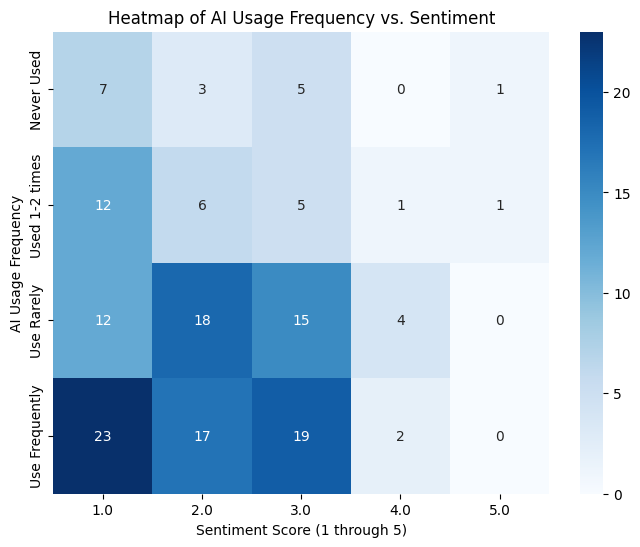

In [ ]:
# create contingency table for heatmap
contingency_table = pd.crosstab(df_clean['AI_Frequency'], df_clean['Sentiment'])

plt.figure(figsize=(8, 6))
sns.heatmap(contingency_table, annot=True, cmap='Blues', fmt='d')
plt.title('Heatmap of AI Usage Frequency vs. Sentiment')
plt.xlabel('Sentiment Score (1 through 5)')
plt.ylabel('AI Usage Frequency')
plt.show()

## Visualization 2 - Stacked Bar Chart

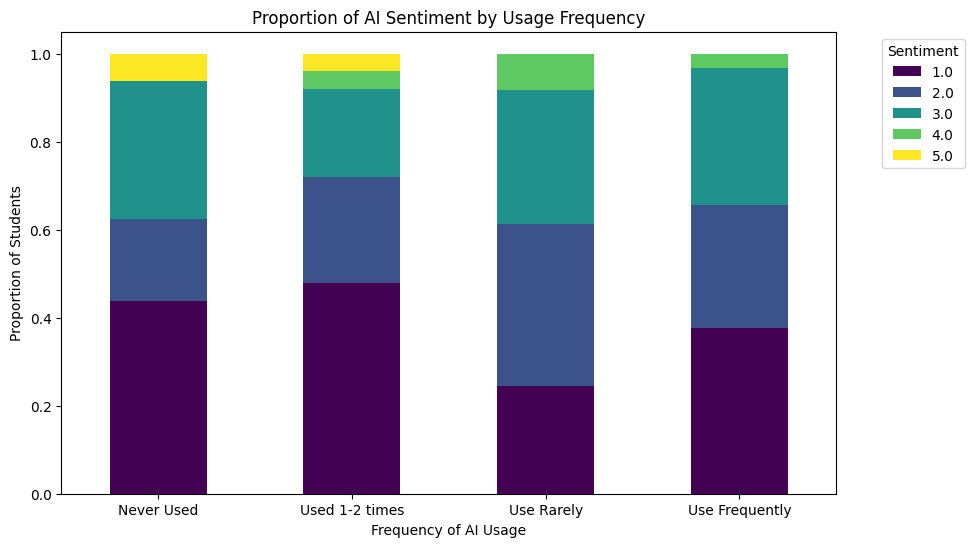

In [ ]:
# cross-tab of proportions
cross_tab_prop = pd.crosstab(df_clean['AI_Frequency'], df_clean['Sentiment'], normalize='index')

cross_tab_prop.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6))
plt.title('Proportion of AI Sentiment by Usage Frequency')
plt.xlabel('Frequency of AI Usage')
plt.ylabel('Proportion of Students')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

## Visualization 3 - 

## Chi-Square Test

Null Hypothesis: 

Alternate Hypothesis: 

In [ ]:
# create contingency table
contingency_table = pd.crosstab(df_clean['AI_Frequency'], df_clean['Sentiment'])

# use contingency to run chi-square test
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

# print statistic
print(f"Chi-Square Statistic: {chi2_stat:.2f}")
print(f"P-value: {p_value:.4f}")

# interpretation
alpha = 0.05
if p_value < alpha:
    print("\nResult: Reject the Null Hypothesis.")
    print("Conclusion:")
else:
    print("\nResult: Fail to reject the Null Hypothesis.")
    print("Conclusion: ")

Chi-Square Statistic: 13.88
P-value: 0.3082

Result: Fail to reject the Null Hypothesis.
Conclusion: 
